# Prediction with CSlearn: Mushroom Example

This notebook shows how to apply CSlearn to a real dataset and use the fitted model for prediction. We use the [UCI Mushroom dataset](https://archive.ics.uci.edu/dataset/73/mushroom) (8124 samples, 22 categorical features) and predict whether a mushroom is poisonous or not.

The workflow has three steps:
1. **Fit** — learn a CStree from training data via `CStree.fit()`.
2. **Save/load** — pickle the fitted model so the slow fit step can be skipped on subsequent runs.
3. **Predict** — call `tree.predict(partial_observations)` on held-out test data.

In [1]:
import pickle
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
from ucimlrepo import fetch_ucirepo

from cslearn.cstree import CStree

## Load and preprocess the data

We fetch the dataset from the UCI repository, drop the constant `veil-type` column, ordinally encode all features, and split into 70% train / 30% test.

In [2]:
mushroom = fetch_ucirepo(id=73)
data = pd.concat([mushroom.data.features, mushroom.data.targets], axis=1)
data.dropna(inplace=True)
data.drop("veil-type", axis=1, inplace=True)  # constant column

encoder = OrdinalEncoder()
ordinalized = encoder.fit_transform(data.values).astype(int)
data = pd.DataFrame(ordinalized, columns=data.columns)

cards = data.nunique().values
train, test = train_test_split(data, test_size=0.3, random_state=0)

print(f"Train: {len(train)} rows | Test: {len(test)} rows | Variables: {len(cards)}")
print(f"Cardinalities: {cards.tolist()}")

Train: 3950 rows | Test: 1694 rows | Variables: 22
Cardinalities: [6, 4, 8, 2, 7, 2, 2, 2, 9, 2, 4, 4, 4, 7, 7, 2, 3, 4, 6, 6, 6, 2]


## Fit the model

`CStree.fit()` runs the three-phase CSlearn pipeline:
1. GRaSP to identify candidate parent sets.
2. Order MCMC (Gibbs sampler) to find the MAP variable ordering.
3. Exact staging search under the β ≤ 2 constraint.

With 22 variables and 3950 training rows this takes several minutes. `save_as="mushroom"` pickles all intermediate results so the fit can be skipped on re-runs.

In [3]:
# The cardinalities row must be the first row of the DataFrame passed to fit().
train_with_cards = train.copy()
train_with_cards.loc[-1] = cards
train_with_cards = train_with_cards.reindex(np.roll(train_with_cards.index, 1)).reset_index(drop=True)

# Fit and save (takes several minutes on first run).
# opt_tree = CStree().fit(train_with_cards, save_as="mushroom")

# Load from a previously saved pickle instead:
with open("mushroom-opt_tree.pkl", "rb") as f:
    opt_tree = pickle.load(f)

## Predict on test data

`predict(partial_observations)` takes a DataFrame of partial observations and returns a DataFrame of predicted values for the unobserved variables. Here we predict the `poisonous` label from all other features.

In [4]:
predict_from = test.drop("poisonous", axis=1)
true_labels = test["poisonous"].values

predictions = opt_tree.predict(predict_from)
predictions.head()

,poisonous
0,1
1,0
2,0
3,0
4,0


## Evaluate

We report overall accuracy and the confusion matrix.

In [5]:
pred_labels = predictions["poisonous"].values
acc = accuracy_score(true_labels, pred_labels)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(true_labels, pred_labels)
print("Confusion matrix (rows=true, cols=predicted):")
print(pd.DataFrame(cm, index=["edible", "poisonous"], columns=["pred edible", "pred poisonous"]))

Accuracy: 0.9581
Confusion matrix (rows=true, cols=predicted):
           pred edible  pred poisonous
edible            1023              30
poisonous           41             600


## Prediction with confidence scores

Pass `return_probs=True` to get the conditional probability of the MAP prediction given the observed features.

In [6]:
predictions_with_probs = opt_tree.predict(predict_from.head(5), return_probs=True)
predictions_with_probs

,poisonous,PROB
0,1,0.999255
1,0,0.999967
2,0,0.999939
3,0,0.998355
4,0,0.999957


## LDAG visualization

Convert the fitted CStree to an LDAG and export it for the paper. Edge labels (CSI context strings) are replaced with single letters via `with_legend=True` -- some run up to ~80 characters, which otherwise dominates the layout's width far more than the 22 node labels do. The letter-to-context mapping is printed below for the paper's legend table.

INFO:pikepdf._core:pikepdf C++ to Python logger bridge initialized


a: [[1]]
b: [[3]]
c: [[0, 1], [1, 1], [3]]
d: [[0, 1], [1, 1], [3]]
e: [[1], [2]]
f: [[0, 0], [1, 0], [2, 0], [3, 0]]
g: [[0, 0], [1, 0], [2, 0], [3, 0]]
h: [[1], [2], [3, 0], [3, 1]]
i: [[0, 0], [0, 1], [0, 2], [0, 3]]
j: [[0, 0], [1, 0], [0, 2], [1, 2], [3]]
k: [[0, 0], [1, 0], [0, 2], [1, 2], [3]]
l: [[0, 0], [1, 0], [2, 0], [3, 0]]
m: [[0, 0], [1, 0], [2, 0], [3, 0]]
n: [[0, 0], [1, 0], [2, 0], [3, 0]]
o: [[0, 1], [1, 1], [2, 1], [3, 1], [2], [3], [4], [0, 5], [1, 5], [2, 5], [3, 5]]
p: [[0, 0], [1, 0], [2, 0], [3, 0], [1], [0, 3], [1, 3], [2, 3], [3, 3], [4], [6]]
q: [[1, 0], [1, 1]]
r: [[0, 1], [1, 1]]
s: [[0, 1], [1, 1]]
t: [[0, 1], [1, 1]]
u: [[0, 1], [1, 1]]
v: [[0, 1], [1, 1]]
w: [[0, 0], [1, 0], [2], [3], [4]]
x: [[1, 0], [1, 1]]
y: [[1], [0, 2], [1, 2], [4], [0, 5], [1, 5], [6]]
z: [[0], [2], [3]]
A: [[1, 0], [1, 1]]
B: [[0], [1], [2]]
C: [[0, 0], [0, 1], [0, 2], [0, 3]]
D: [[0, 0], [1, 0], [1], [2]]
E: [[0], [1], [2], [3], [4], [6]]
F: [[0, 0], [0, 1]]


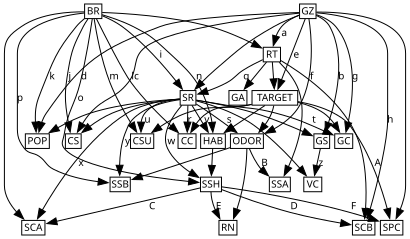

In [7]:
from string import ascii_letters

ldag = opt_tree.to_LDAG()
letter_of = {}
_strs = iter(ascii_letters)
for pa, ch, attr in ldag.edges(data=True):
    if "label" not in attr:
        continue
    letter_of[(pa, ch)] = next(_strs)

# Full node names (e.g. "stalk-surface-above-ring") dominate the layout's
# width even more than the edge labels; abbreviate to short mnemonic codes,
# applied before layout so box sizes reflect the abbreviation.
NODE_ABBREV = {
    "stalk-surface-above-ring": "SSA", "stalk-surface-below-ring": "SSB",
    "stalk-color-above-ring": "SCA", "stalk-color-below-ring": "SCB",
    "spore-print-color": "SPC", "gill-attachment": "GA", "gill-spacing": "GS",
    "gill-color": "GC", "gill-size": "GZ", "cap-shape": "CS", "cap-surface": "CSU",
    "cap-color": "CC", "stalk-shape": "SSH", "stalk-root": "SR", "veil-color": "VC",
    "ring-number": "RN", "ring-type": "RT", "population": "POP", "habitat": "HAB",
    "bruises": "BR", "odor": "ODOR", "poisonous": "TARGET",
}
assert set(NODE_ABBREV) == set(ldag.nodes()), set(ldag.nodes()) ^ set(NODE_ABBREV)
assert len(set(NODE_ABBREV.values())) == len(NODE_ABBREV), "duplicate abbreviations"

agraph, legend = ldag.plot_graphviz(
    with_legend=True, nodesep="0.075", ranksep="0.115", margin="0.021,0.013",
    node_labels=NODE_ABBREV,
)
agraph.draw("mushroom-ldag.pdf")

# Losslessly crop to the drawing's ink bounding box (+3pt margin) by
# rewriting the page box in place -- no re-rendering, so the embedded 10pt
# font is untouched. Requires ghostscript on PATH (`nix-shell -p ghostscript`
# if not already available) and the `pikepdf` package.
import subprocess

import pikepdf


def crop_to_content(path, margin=3.0):
    result = subprocess.run(
        ["gs", "-q", "-dBATCH", "-dNOPAUSE", "-sDEVICE=bbox", path],
        capture_output=True, text=True, check=True,
    )
    line = [l for l in result.stderr.splitlines() if l.startswith("%%HiResBoundingBox:")][0]
    x0, y0, x1, y1 = (float(v) for v in line.split(":")[1].split())
    box = pikepdf.Array([x0 - margin, y0 - margin, x1 + margin, y1 + margin])
    pdf = pikepdf.open(path, allow_overwriting_input=True)
    pdf.pages[0].MediaBox = box
    pdf.pages[0].CropBox = box
    pdf.save(path)


crop_to_content("mushroom-ldag.pdf")
for letter, context in legend.items():
    print(f"{letter}: {context}")
agraph

## Semantic edge-label context table

Translate each edge's context (currently only shown as raw encoded
values above) into real feature names and categories, using the fitted
`OrdinalEncoder`'s `categories_`. Matches ALARM's table style: one row
per edge label, joining that label's CSI relations within the cell.

In [8]:
_, contexts = opt_tree.to_LDAG(return_contexts=True)
col_idx_of = {name: i for i, name in enumerate(data.columns)}

# ucimlrepo's metadata gives each feature's code-to-name legend as a
# "name=code,name=code,..." string; parse it once so contexts show real
# category names ("cap-shape = bell") instead of single-letter codes.
code_to_name = {}
for _, row in mushroom.variables.iterrows():
    if pd.isna(row["description"]):
        continue
    mapping = {}
    for pair in row["description"].split(","):
        pair = pair.strip()
        if "=" not in pair:
            continue
        name, code = pair.rsplit("=", 1)
        mapping[code.strip()] = name.strip()
    code_to_name[row["name"]] = mapping
# "poisonous" (the target) has no UCI metadata description; e/p is the
# standard encoding for this dataset.
code_to_name["poisonous"] = {"e": "edible", "p": "poisonous"}

def relation_str(relation):
    parts = []
    for var_name, value in relation:
        code = encoder.categories_[col_idx_of[var_name]][value]
        category = code_to_name.get(var_name, {}).get(code, code)
        parts.append(f"{var_name} = {category}")
    return ", ".join(parts)

rows = []
for (k, v), letter in letter_of.items():
    relations = contexts[(k, v)]
    cell = " \\\\ ".join(relation_str(r) for r in relations)
    rows.append((letter, cell))
rows.sort(key=lambda r: ascii_letters.index(r[0]))

print("% Edge-label context table")
for letter, cell in rows:
    print(f"{letter} & \\makecell[l]{{{cell}}} \\\\")
    print("\\midrule")

print()
print("% Node-abbreviation table (Figure 8)")
for name, code in sorted(NODE_ABBREV.items(), key=lambda kv: kv[1]):
    print(f"{code} & {name} \\\\")
    print("\\midrule")

% Edge-label context table
a & \makecell[l]{bruises = bruises} \\
\midrule
b & \makecell[l]{stalk-root = rooted} \\
\midrule
c & \makecell[l]{bruises = no, stalk-root = club \\ bruises = bruises, stalk-root = club \\ stalk-root = rooted} \\
\midrule
d & \makecell[l]{bruises = no, stalk-root = club \\ bruises = bruises, stalk-root = club \\ stalk-root = rooted} \\
\midrule
e & \makecell[l]{ring-type = large \\ ring-type = none} \\
\midrule
f & \makecell[l]{stalk-root = bulbous, poisonous = edible \\ stalk-root = club, poisonous = edible \\ stalk-root = equal, poisonous = edible \\ stalk-root = rooted, poisonous = edible} \\
\midrule
g & \makecell[l]{stalk-root = bulbous, poisonous = edible \\ stalk-root = club, poisonous = edible \\ stalk-root = equal, poisonous = edible \\ stalk-root = rooted, poisonous = edible} \\
\midrule
h & \makecell[l]{ring-type = large \\ ring-type = none \\ ring-type = pendant, stalk-shape = enlarging \\ ring-type = pendant, stalk-shape = tapering} \\
\midrule
